## Simulation d'un processus de Hawkes par thinning

On reprend l'exemple du Hawkes linéaire exponentiel $Z$ dont l'intensité est donnée par:
$$\lambda(t)=\mu+\int_0^t\alpha\beta e^{-\beta(t-s)}dZ_s.$$

On va chercher à estimer les quantités inconnues $\theta=(\mu,\alpha,\beta)$.

In [ ]:
import numpy as np
from scipy.stats import kstest
from scipy.optimize import minimize
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from pathlib import Path

np.random.seed(42)



def simu_hawkes(mu,alpha,beta,Tmax):
    t=0
    events=[]
    lambda_t=mu
    while t<Tmax:
        lambda_sup=lambda_t
        incr=np.random.exponential(1/lambda_sup)
        t_cand=t+incr
        if t_cand > Tmax:
            break
        U=np.random.uniform(0,1)
        lambda_cand=lambda_t*np.exp(-beta*incr)+mu*(1-np.exp(-beta*incr))
        if U < lambda_cand/lambda_sup:
            events.append(t_cand)
            lambda_t=lambda_cand+alpha*beta
        else:
            lambda_t=lambda_cand
        t=t_cand
    return(np.array(events))

1 - On peut tester la valeur terminale: on sait que pour un Hawkes linéaire dont $\|h\|_1<1$, $$\frac{Z_t}t\to \frac{\mu}{1-\|h\|_1}$$ en probabilité.

In [ ]:
mu = 1
alpha= 0.5 # Choisir alpha < 1 这个alpha就是h的L1范数
beta = 1
Tmax = 2000
events = simu_hawkes(mu, alpha, beta, Tmax)

Z_T = len(events)          # 事件数
rate_emp = Z_T / Tmax      # Z_T / T
rate_theo = mu / (1 - alpha)

print("Z_T =", Z_T)
print("Empirical Z_T/T =", rate_emp)
print("Theoretical mu/(1-alpha) =", rate_theo)
print("Absolute error =", abs(rate_emp - rate_theo))

Z_T = 4050
Empirical Z_T/T = 2.025
Theoretical mu/(1-alpha) = 2.0
Absolute error = 0.02499999999999991


2 - Construire une fonction qui calcule l'intensité du Hawkes en un point de $t$. Tracer l'intensité et indiquer les instants de sauts sur un même graphique.

In [ ]:
def hawkes_intensity(t, events, mu, alpha, beta):
    """
    Compute lambda(t) = mu + sum_{Ti < t} alpha*beta*exp(-beta*(t-Ti)).
    """
    ev = np.array(events)

    past = ev[ev < t]
    if past.size == 0:
        return mu

    return mu + np.sum(alpha * beta * np.exp(-beta * (t - past)))

Regarder graphiquement ce qu'il se passe si $\alpha>1$.

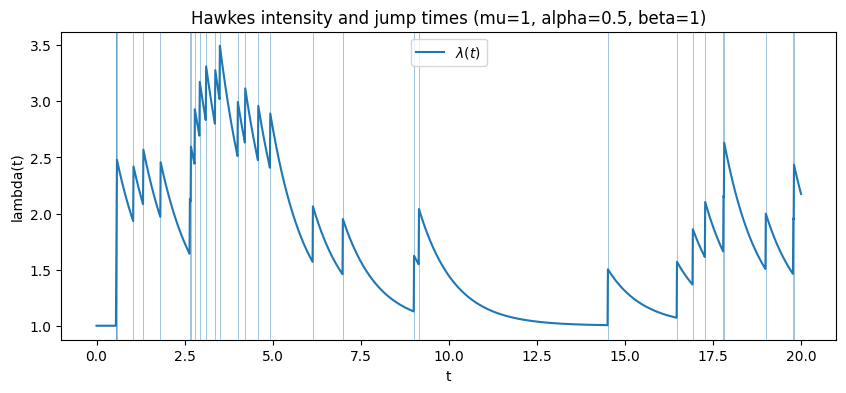

Number of events: 4050


In [ ]:

plot_horizon = 20
grid = np.linspace(0, plot_horizon, 2000)
lam = np.array([hawkes_intensity(t, events, mu, alpha, beta) for t in grid])

plt.figure(figsize=(10, 4))
plt.plot(grid, lam, linewidth=1.5, label=r'$\lambda(t)$')
for ti in events[(events > 0) & (events < plot_horizon)]:
    plt.axvline(ti, linewidth=0.6, alpha=0.35, color="tab:red")
plt.title(f"Stable Hawkes process: intensity and events ($\\alpha={alpha}$)")
plt.xlabel("time")
plt.ylabel("intensity")
plt.legend()
plt.show()


### Supercritical regime

When $\alpha>1$, the branching ratio exceeds one. The process is no longer stationary:
each event creates, on average, more than one descendant, so event clusters and the
conditional intensity can grow very rapidly.


In [ ]:
mu_super, alpha_super, beta_super, horizon_super = 0.2, 1.05, 1.0, 12
events_super = simu_hawkes(mu_super, alpha_super, beta_super, horizon_super)
grid_super = np.linspace(0, horizon_super, 1500)
lam_super = np.array([
    hawkes_intensity(t, events_super, mu_super, alpha_super, beta_super)
    for t in grid_super
])

plt.figure(figsize=(10, 4))
plt.plot(grid_super, lam_super, label=r'$\lambda(t)$')
plt.scatter(events_super, np.zeros_like(events_super), s=10, color="tab:red", label="events")
plt.title(r"Illustration of the supercritical regime ($\alpha>1$)")
plt.xlabel("time")
plt.ylabel("intensity")
plt.legend()
plt.show()
print("Number of events:", len(events_super))


## Compensateur

3 - Construire une fonction qui calcule le compensateur: $\Lambda(t)=\int_0^t\lambda(s)ds.$

On considère un processus de Hawkes linéaire d’intensité
$$
\lambda(t)=\mu+\sum_{i:\,T_i<t}\alpha\beta\,e^{-\beta(t-T_i)}.
$$

Le compensateur est défini par
$$
\Lambda(t)=\int_0^t \lambda(s)\,ds.
$$

Dans le cas du noyau exponentiel, on obtient une expression fermée. En effet, pour chaque saut $T_i<t$,
$$
\int_{T_i}^{t}\alpha\beta\,e^{-\beta(s-T_i)}\,ds
=
\alpha\Bigl(1-e^{-\beta(t-T_i)}\Bigr).
$$

Ainsi,
$$
\Lambda(t)
=
\mu t
+
\sum_{i:\,T_i<t}
\alpha\Bigl(1-e^{-\beta(t-T_i)}\Bigr).
$$

In [ ]:
#补偿器 计算增量，两个补偿器的差，然后他们应该复合E（namda）
def hawkes_compensator(t, events, mu, alpha, beta):
    """
    Lambda(t) = ∫_0^t lambda(s) ds
              = mu*t + sum_{Ti < t} alpha*(1 - exp(-beta*(t-Ti))).
    """
    ev = np.array(events)
    past = ev[ev < t]
    return mu * t + np.sum(alpha * (1.0 - np.exp(-beta * (t - past))))

## Test d'ajustement

4 - En utilisant le résultat du cours, vérifier par un test d'ajustement l'adéquation de $(\Lambda(T_j)-\Lambda(T_{j-1}), j\ge 1)$ à une loi exponentielle. Tracer l'histogramme associé et le comparer à la densité exponentielle.

Number of deltas: 4050
Empirical mean of deltas: 0.9939430915511236  (theoretical mean=1)
KS statistic: 0.008927461686306495
p-value: 0.9005071759655464


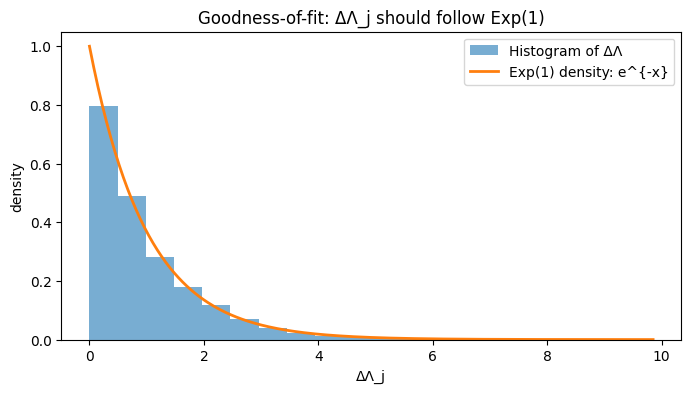

In [ ]:
events = np.array(events, dtype=float)
events = np.sort(events)
events = events[events > 0]
events = np.unique(events)
# events要处理一下不然后面算liklihood的时候出问题

# 计算补偿器在每个跳点的值 S_j = Λ(T_j)
S = np.array([hawkes_compensator(t, events, mu, alpha, beta) for t in events])

# Δ_j = S_j - S_{j-1}, 其中 S_0 := 0
deltas = np.diff(np.concatenate(([0.0], S)))

print("Number of deltas:", len(deltas))
print("Empirical mean of deltas:", deltas.mean(), " (theoretical mean=1)")

# 1) KS test against Exp(1)
# scipy 的 expon 默认 scale=1 即 Exp(1)
stat, pval = kstest(deltas, 'expon')
print("KS statistic:", stat)
print("p-value:", pval)

# 2) Histogram + theoretical density e^{-x} 1_{x>=0}
plt.figure(figsize=(8,4))
plt.hist(deltas, bins=20, density=True, alpha=0.6, label="Histogram of ΔΛ")
x = np.linspace(0, np.max(deltas), 400)
plt.plot(x, np.exp(-x), linewidth=2, label="Exp(1) density: e^{-x}")
plt.title("Goodness-of-fit: ΔΛ_j should follow Exp(1)")
plt.xlabel("ΔΛ_j")
plt.ylabel("density")
plt.legend()
plt.show()

## Vraisemblance

5 - Ecrire la vraisemblance dans ce cas.

On observe les instants de saut $0<T_1<\cdots<T_n\le T$ d’un processus ponctuel d’intensité $\lambda_\theta(t)$.
La vraisemblance sur $[0,T]$ s’écrit
$$
L(\theta)=\left(\prod_{i=1}^n \lambda_\theta(T_i)\right)
\exp\!\left(-\int_0^T \lambda_\theta(s)\,ds\right).
$$

Donc la log-vraisemblance est
$$
\ell(\theta)=\sum_{i=1}^n \log\lambda_\theta(T_i)-\Lambda_\theta(T),
\qquad
\Lambda_\theta(T)=\int_0^T \lambda_\theta(s)\,ds.
$$

Dans le cas Hawkes exponentiel,
$$
\lambda(t)=\mu+\sum_{i:\,T_i<t}\alpha\beta\,e^{-\beta(t-T_i)},
$$
et
$$
\Lambda(T)=\mu T+\sum_{i:\,T_i<T}\alpha\Bigl(1-e^{-\beta(T-T_i)}\Bigr).
$$

Ainsi, une expression explicite de la log-vraisemblance est
$$
\ell(\mu,\alpha,\beta)
=
\sum_{k=1}^n
\log\!\left(
\mu+\sum_{i=1}^{k-1}\alpha\beta\,e^{-\beta(T_k-T_i)}
\right)
-
\mu T
-
\sum_{i=1}^n
\alpha\Bigl(1-e^{-\beta(T-T_i)}\Bigr).
$$

In [ ]:
def log_likelihood(theta, events):
    mu, alpha, beta = theta

    T = events[-1]
    n = len(events)

    if mu <= 0 or alpha <= 0 or beta <= 0:
        return np.inf

    log_sum = 0

    for k in range(n):
        Tk = events[k]
        lambda_k = mu

        for i in range(k):
            lambda_k += alpha * beta * np.exp(-beta * (Tk - events[i]))

        if lambda_k <= 0:
            return np.inf

        log_sum += np.log(lambda_k)

    compensator = mu * T + np.sum(alpha * (1 - np.exp(-beta * (T - events))))

    return -(log_sum - compensator)

## Maximum de vraisemblance

In [ ]:
epsilon=1e-5
bounds=((epsilon, None), (epsilon, 1-epsilon), (epsilon, None))
init=np.array((1,0,1))

In [ ]:

fit = minimize(
    fun=log_likelihood,
    x0=init,
    args=(events,),
    method="L-BFGS-B",
    bounds=bounds,
)
print("Converged:", fit.success)
print(f"Estimated parameters: mu={fit.x[0]:.3f}, alpha={fit.x[1]:.3f}, beta={fit.x[2]:.3f}")
print("True parameters:      mu=1.000, alpha=0.500, beta=1.000")


## Optional Memetracker application

The original exercise uses a Memetracker phrase cascade. The raw course data are not
redistributed in this repository. If the file `data/clust-qt08080902w3mfq5.txt` is
available locally, the following cells extract one cascade, estimate a Hawkes model,
and apply the time-rescaling goodness-of-fit test.


In [ ]:
data_path = Path("../data/clust-qt08080902w3mfq5.txt")

if data_path.exists():
    table = pd.read_csv(
        data_path, skiprows=4, sep="\t", names=["a", "b", "c", "d", "e", "f"]
    )
    valid_rows = table.index[table["a"].notna()]
    cascade_id = 137082
    positions = [
        k for k, idx in enumerate(valid_rows[:-1])
        if str(table.loc[idx, "d"]).strip().isdigit()
        and int(table.loc[idx, "d"]) == cascade_id
    ]
    if not positions:
        raise ValueError(f"Cascade {cascade_id} was not found in the data file.")

    k = positions[0]
    cascade = table.iloc[valid_rows[k]:valid_rows[k + 1]]
    timestamps = []
    for value in cascade["c"]:
        try:
            timestamps.append(datetime.strptime(value, "%Y-%m-%d %H:%M:%S").timestamp())
        except (TypeError, ValueError):
            pass

    twitter_events = np.sort(np.asarray(timestamps) - timestamps[0]) / 20**5
    twitter_events = np.unique(twitter_events[twitter_events > 0])
    print(f"Extracted {len(twitter_events)} event times.")
else:
    twitter_events = None
    print(f"Optional data file not found: {data_path}")


In [ ]:
if twitter_events is not None and len(twitter_events) >= 3:
    twitter_fit = minimize(
        log_likelihood,
        x0=np.array([1.0, 0.5, 1.0]),
        args=(twitter_events,),
        method="L-BFGS-B",
        bounds=bounds,
    )
    mu_hat, alpha_hat, beta_hat = twitter_fit.x
    print("Converged:", twitter_fit.success)
    print(f"mu={mu_hat:.4f}, alpha={alpha_hat:.4f}, beta={beta_hat:.4f}")

    transformed = np.array([
        hawkes_compensator(t, twitter_events, mu_hat, alpha_hat, beta_hat)
        for t in twitter_events
    ])
    residuals = np.diff(np.r_[0.0, transformed])
    ks_stat, ks_pvalue = kstest(residuals, "expon")
    print(f"KS statistic={ks_stat:.4f}, p-value={ks_pvalue:.4f}")

    plt.figure(figsize=(8, 4))
    plt.hist(residuals, bins=20, density=True, alpha=0.6, label="rescaled intervals")
    x = np.linspace(0, residuals.max(), 300)
    plt.plot(x, np.exp(-x), linewidth=2, label="Exp(1) density")
    plt.xlabel(r'$\Delta\Lambda_j$')
    plt.ylabel("density")
    plt.title("Memetracker Hawkes goodness-of-fit")
    plt.legend()
    plt.show()
else:
    print("Memetracker estimation skipped; add the optional data file to run it.")


## Conclusions

- In the stable regime, the empirical event rate is close to the theoretical limit
  $\mu/(1-\alpha)$.
- The intensity jumps after each event and then decays exponentially toward the baseline.
- Time-rescaled inter-event intervals are consistent with an $\mathrm{Exp}(1)$ law in
  the simulated experiment, supporting the fitted model specification.
- The supercritical experiment illustrates why $\alpha<1$ is the stationarity condition.
- The same likelihood and diagnostic pipeline can be applied to a real event cascade when
  the optional Memetracker data are available.
